# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science & IA**
### *Pipeline de datos: Bronze → Silver*
---

**Fuente de datos:** Encuesta de Condiciones de Vida (ECV) 2025, INE  
**Población objetivo:** Asalariados en activo residentes en la Comunidad de Madrid  
**Resultado de esta capa:** `dataset_analitico.csv` — dataset limpio listo para modelado

---

### *Estructura del notebook*

Este notebook documenta y justifica cada decisión del pipeline de preparación de datos siguiendo la **arquitectura medallón**:

| Capa | Contenido |
|------|-----------|
| 🥉 **Bronze** | Exploración de los datos en crudo tal como los publica el INE |
| 🥈 **Silver** | Limpieza, joins, filtros, imputación, renombrado y decodificación |
| 🥇 **Gold**   | Construcción del target `estres_financiero_alto`, feature engineering y encoding para modelado |  


> **Nota metodológica:** Este notebook reproduce la lógica del script `limpieza_ecv.py` de forma narrativa y exploratoria. El código de producción queda en el script; aquí el objetivo es documentar y visualizar cada decisión para la memoria del TFM.

---

## 0. **Configuración del entorno**

Librerías estándar de análisis de datos. No se requieren dependencias adicionales.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from utils.cleaning_utils import cargar_csv

from utils.visualizations_utils import nuls_space_dis, diagram_relationship

# Estilo visual 
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
})


## 1. **CAPA BRONZE - Datos en crudo**

La capa Bronze almacena los microdatos exactamente tal como los publica el INE, sin ninguna transformación. Su único propósito es dar visibilidad a la estructura original y justificar las decisiones de la capa Silver.

### B.1 **Los cuatro ficheros del INE**

Los microdatos de la ECV 2025 se distribuyen en **cuatro ficheros CSV**, cada uno con un prefijo numérico que lo identifica. Cada variable lleva un prefijo de letra que indica a qué fichero pertenece:

| Fichero | Prefijo variable | Contenido |
|---------|-----------------|-----------|
| `01_datos_hogar.csv` | D | Región, urbanización, peso muestral del hogar |
| `02_detalles_hogar.csv` | H | Renta, vivienda, carencias materiales, indicadores de bienestar |
| `03_detalles_adulto.csv` | P | Datos laborales, educación, salud, renta individual |
| `04_datos_persona.csv` | R | Demográficos + variables derivadas de pobreza/exclusión |

Los ficheros de metadatos (`.xlsx`) en `data/01_bronze/info/` describen cada variable y sus tablas de códigos.


In [2]:
#  Carga de los 4 ficheros originales

df_d = cargar_csv('01_datos_hogar.csv')       # D: datos básicos hogar
df_h = cargar_csv('02_detalles_hogar.csv')    # H: detalle hogar
df_p = cargar_csv('03_detalles_adulto.csv')   # P: datos adulto
df_r = cargar_csv('04_datos_persona.csv')     # R: datos persona

resumen = pd.DataFrame({
    'Fichero':    ['01_datos_hogar', '02_detalles_hogar', '03_detalles_adulto', '04_datos_persona'],
    'Prefijo':    ['D', 'H', 'P', 'R'],
    'Filas':      [len(df_d), len(df_h), len(df_p), len(df_r)],
    'Columnas':   [df_d.shape[1], df_h.shape[1], df_p.shape[1], df_r.shape[1]],
})

resumen

,Fichero,Prefijo,Filas,Columnas
0,01_datos_hogar,D,29369,9
1,02_detalles_hogar,H,29369,156
2,03_detalles_adulto,P,60825,245
3,04_datos_persona,R,71398,46


### B.2 **Características del formato original**

El INE publica los microdatos con un formato que requiere tratamiento específico antes de poder analizarlos. Los puntos clave que condiciona toda la limpieza posterior son:

#### B.2.1 **Todas las columnas vienen como string**

Aunque la mayoría de variables son códigos numéricos, el INE las almacena como texto. Esto implica que no se pueden aplicar filtros numéricos directamente y que las cadenas vacías `''` son el nulo real del INE (no `NaN`).

In [3]:
# Demostración: tipos de datos en bruto
print('Tipos de datos en fichero D (primeras 9 columnas):')
print(df_d.dtypes.to_string())
print()
print('Valores únicos en DB040 (región):', df_d['DB040'].unique()[:5])
print('Tipo de DB040:', df_d['DB040'].dtype)


Tipos de datos en fichero D (primeras 9 columnas):
DB010        int64
DB020          str
DB030        int64
DB040          str
DB040_F      int64
DB090      float64
DB090_F      int64
DB100        int64
DB100_F      int64

Valores únicos en DB040 (región): <StringArray>
['ES21', 'ES42', 'ES61', 'ES52', 'ES30']
Length: 5, dtype: str
Tipo de DB040: str


#### B.2.2 **Cadena vacía `''` como nulo real**

La cadena vacía `' '` (espacio) o `''` es el indicador de dato faltante del INE, no el `NaN` de pandas. **Los códigos negativos (-1, -2, -4, -5, -6) son nulos en variables numéricas continuas**, pero no en las categóricas donde esos valores tienen significado.

Comprobamos su presencia en los componentes del estrés financiero:

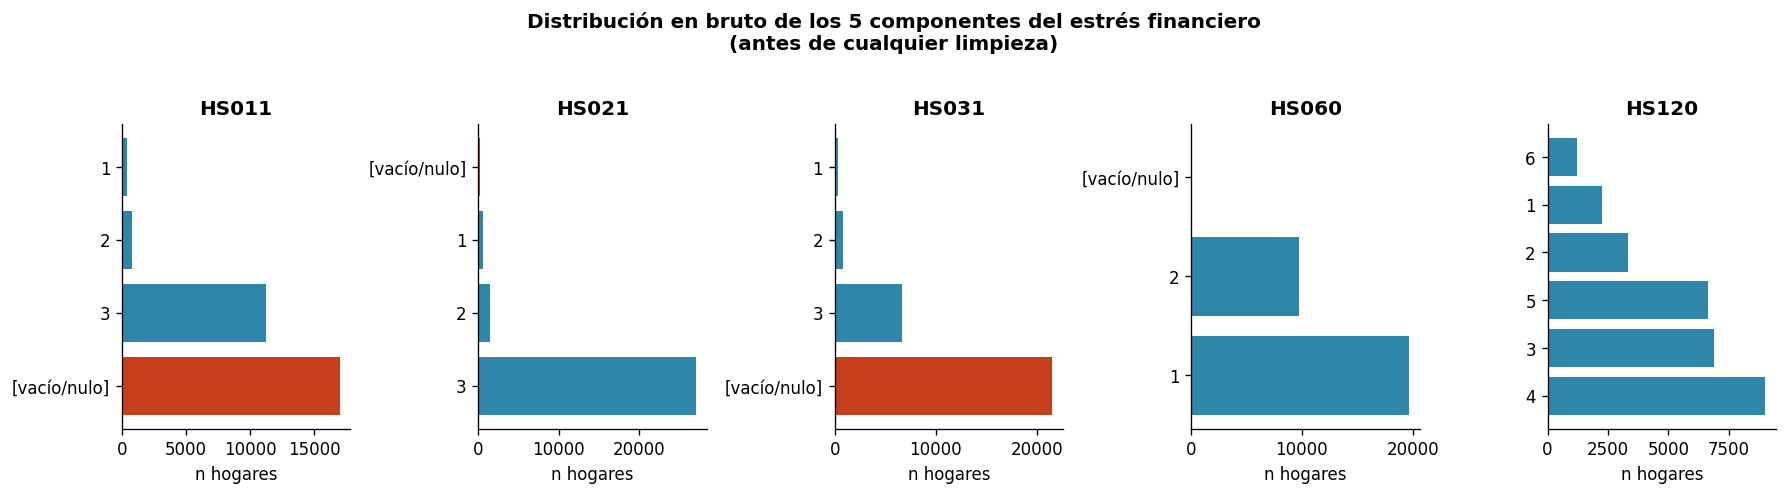

Nota: las barras rojas representan valores faltantes según el INE (cadena vacía).


In [4]:
# Visualizar distribución de nulos-como-espacio en variables target
target_raw = ['HS011', 'HS021', 'HS031', 'HS060', 'HS120']

nuls_space_dis(df_h, target_raw)

#### B.2.3 **Flags de calidad `_F`**

Cada variable principal del cuestionario tiene su correspondiente **variable bandera** (sufijo `_F`) que codifica el estado de respuesta:

| Código flag | Significado |
|-------------|-------------|
| `1`         | Variable recogida en el cuestionario |
| `-1`        | No consta (respuesta ausente) |
| `-2`        | No aplicable (pregunta no correspondía a esa persona/hogar) o No disponible|
| `-4`        | No autoriza el uso |

Estos flags son **metadatos de calidad del INE**, no información sustantiva. En la capa Silver se usarán para imputar NaN en las variables correspondientes y luego se eliminarán.


In [5]:
# Ejemplo de flags: HS011 (retrasos hipoteca/alquiler) y su flag HS011_F
hs011_flag = df_h[['HS011', 'HS011_F']].copy()
print('Valores únicos en HS011_F (flag):', sorted(hs011_flag['HS011_F'].unique()))
print()
print('Cruces HS011 × HS011_F:')
cross = pd.crosstab(
    hs011_flag['HS011'].fillna('NaN').replace('', '[vacío]').replace(' ', '[vacío]'),
    hs011_flag['HS011_F'].fillna('NaN'),
    margins=True
)
print(cross)
print()
print('-> Cuando HS011_F = -2 (No aplicable), HS011 está vacío: son hogares sin hipoteca ni alquiler.')
print('  Esto es un nulo ESTRUCTURAL, no un error de datos.')


Valores únicos en HS011_F (flag): [np.int64(-2), np.int64(-1), np.int64(1)]

Cruces HS011 × HS011_F:
HS011_F     -2  -1      1    All
HS011                           
1            0   0    376    376
2            0   0    792    792
3            0   0  11218  11218
[vacío]  16885  98      0  16983
All      16885  98  12386  29369

-> Cuando HS011_F = -2 (No aplicable), HS011 está vacío: son hogares sin hipoteca ni alquiler.
  Esto es un nulo ESTRUCTURAL, no un error de datos.


### B.2.4 Claves de join entre ficheros

Los cuatro ficheros se unen mediante las siguientes claves:

```
D + H:  DB030 (D) = HB030 (H)          → join hogar
R + P:  RB030 (R) = PB030 (P)          → join persona
Persona → Hogar:  RB030 // 100 = DB030 → join persona-hogar
```

Basándonos en la documentación obtenida del INE, la relación persona-hogar se obtiene dividiendo el ID de persona entre 100, ya que el INE construye `RB030` concatenando el ID de hogar con un sufijo de dos dígitos que identifica al miembro.


In [6]:
# Demostración de la clave de join
ejemplo_r = df_r[['RB030']].head(5).copy()
ejemplo_r['RB030 // 100'] = ejemplo_r['RB030'].astype(int) // 100
print('Relación RB030 → ID hogar:')
print(ejemplo_r.to_string(index=False))
print()
# Verificar que los IDs derivados coinciden con DB030
ids_hogar_D = set(df_d['DB030'].unique())
ids_derivados = set((df_r['RB030'].astype(int) // 100).unique())
interseccion = ids_hogar_D & ids_derivados
print(f'IDs de hogar en D:               {len(ids_hogar_D):,}')
print(f'IDs derivados de R (RB030//100): {len(ids_derivados):,}')
print(f'Intersección (coinciden):        {len(interseccion):,}')


Relación RB030 → ID hogar:
 RB030  RB030 // 100
   101             1
   201             2
   202             2
   301             3
   302             3

IDs de hogar en D:               29,369
IDs derivados de R (RB030//100): 29,369
Intersección (coinciden):        29,369


### B.2.5 Cardinalidad y cobertura de los ficheros


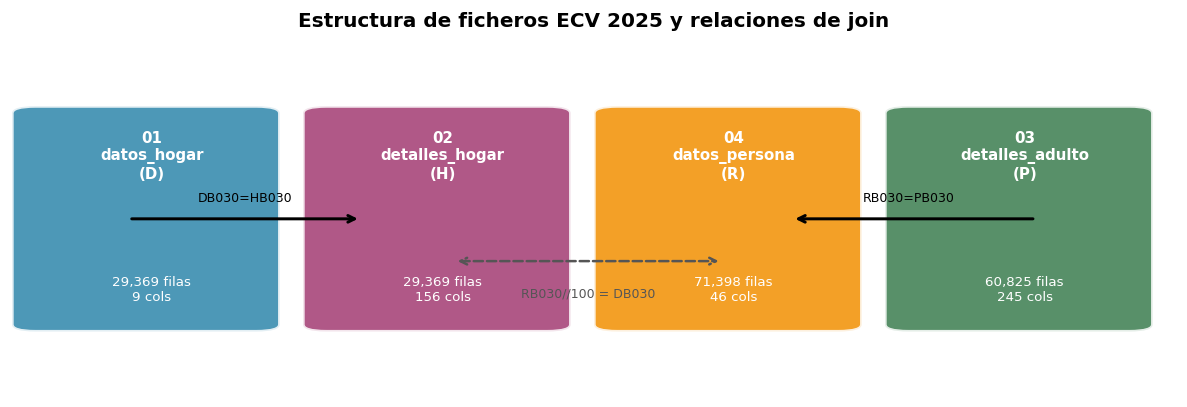

In [7]:
# Diagrama de cobertura y relaciones
diagram_relationship()